# Modelado Avanzado: Feature Engineering y Refactorización

En este notebook vamos a abordar dos objetivos clave:
1. **Mejorar la Precisión y reducir Falsos Positivos**: Ajustando los pesos de las clases, implementando *Feature Engineering* y optimizando el umbral de decisión.
2. **Uso de la Arquitectura del Proyecto**: A partir de ahora, ya no reescribiremos funciones largas aquí. Importaremos la lógica desde las carpetas `src/` y `data/`.


In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importando desde la estructura de nuestro repositorio
# (Asegúrate de que la terminal o el kernel reconozcan la raíz del proyecto)
sys.path.append('..')
from data.loader import load_bank_data
from src.features.build_features import BankFeatureEngineer
from src.models.train_model import build_logistic_pipeline, optimize_threshold

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

# Configuración Visual
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

SEED = 42
np.random.seed(SEED)


## 1. Carga de Datos Modular

Gracias a la refactorización, toda la lógica de ingesta de datos y limpieza de `duration` está empaquetada en `data/loader.py`.


In [2]:
# Cargar datos usando nuestro módulo personalizado
X, y = load_bank_data(drop_duration=True)

# Train/Validation/Test Split
# 1. Separar Test (20%) y el resto (80%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# 2. Separar el resto en Train (75% de temp, que es 60% del total) y Validation (25% de temp, que es 20% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

print(f"Datos cargados.\n")
print(f"Dimensiones de entrenamiento: {X_train.shape}\n")
print(f"Dimensiones de validación: {X_val.shape}\n")
print(f"Dimensiones de prueba: {X_test.shape}\n")


Descargando el dataset 'Bank Marketing' (ID 222)...


Variable 'duration' omitida correctamente.
Datos cargados.

Dimensiones de entrenamiento: (27126, 15)

Dimensiones de validación: (9042, 15)

Dimensiones de prueba: (9043, 15)



## 2. Feature Engineering y Pesos de Clase

En `src/features/build_features.py` creamos un transformador personalizado `BankFeatureEngineer` que extrae automáticamente nuevas variables:
- **Demografía**: Segmentos de edad (is_senior, is_young).
- **Finanzas**: Detección de balance negativo o alto.
- **Comportamiento**: Ajuste de la variable `pdays` (días desde el último contacto) y si hubo contacto previo.

Además, en lugar de usar `class_weight='balanced'` (que sacrifica demasiada precisión por recall, dándole a la clase 1 un peso de casi 9x), **usaremos un peso personalizado de `class_weight={0: 1, 1: 3}`**. Esto le dice al modelo: *'Preocúpate más por los compradores, pero no te vuelvas loco prediciendo puros falsos positivos'*.


In [3]:
from sklearn.model_selection import cross_val_score

# Construimos el pipeline completo importando la lógica de src/models/train_model.py
pipeline = build_logistic_pipeline(X_train, class_weight={0: 1, 1: 3})

# Validación cruzada (Cross-Validation) de 5 folds usando roc_auc
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')

print(f"Puntuaciones de validación cruzada (AUC-ROC): {cv_scores}\n")
print(f"AUC-ROC Promedio (CV): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}\n")

# Entrenar el modelo en todo el conjunto de entrenamiento
pipeline.fit(X_train, y_train)

print("Pipeline entrenado con Feature Engineering incluido.\n")


Puntuaciones de validación cruzada (AUC-ROC): [0.75785438 0.78255957 0.77114424 0.78094587 0.73078888]

AUC-ROC Promedio (CV): 0.7647 +/- 0.0191



Pipeline entrenado con Feature Engineering incluido.



## 3. Evaluación Inicial y Optimización de Umbral

Por defecto, la regresión logística clasifica como '1' si la probabilidad es mayor al **50%**. Podemos jugar con ese umbral usando la función `optimize_threshold` que creamos en nuestro módulo.


In [4]:
# Encontrar el mejor umbral en los datos de VALIDACION (no en train para evitar overfitting del umbral)
best_threshold, best_f1 = optimize_threshold(pipeline, X_val, y_val)

print(f"Umbral óptimo encontrado: {best_threshold:.4f} (F1 Score esperado en validación: {best_f1:.4f})\n")

# Predicciones con umbral por defecto (0.50) en TEST
y_pred_default = pipeline.predict(X_test)

# Predicciones con umbral optimizado en TEST
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred_opt = (y_pred_proba >= best_threshold).astype(int)


Umbral óptimo encontrado: 0.4355 (F1 Score esperado en validación: 0.4593)



### Comparación de Resultados
Veamos cómo mejora la Precisión y bajan los Falsos Positivos frente al notebook anterior (donde la Precisión era del 27%).


In [5]:
print("=== RESULTADOS CON UMBRAL POR DEFECTO (0.50) ===")
print(classification_report(y_test, y_pred_default))

print("\n=== RESULTADOS CON UMBRAL OPTIMIZADO ===")
print(classification_report(y_test, y_pred_opt))


=== RESULTADOS CON UMBRAL POR DEFECTO (0.50) ===
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      7985
           1       0.52      0.38      0.44      1058

    accuracy                           0.89      9043
   macro avg       0.72      0.67      0.69      9043
weighted avg       0.87      0.89      0.88      9043


=== RESULTADOS CON UMBRAL OPTIMIZADO ===
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7985
           1       0.47      0.44      0.45      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.69      0.69      9043
weighted avg       0.87      0.88      0.87      9043



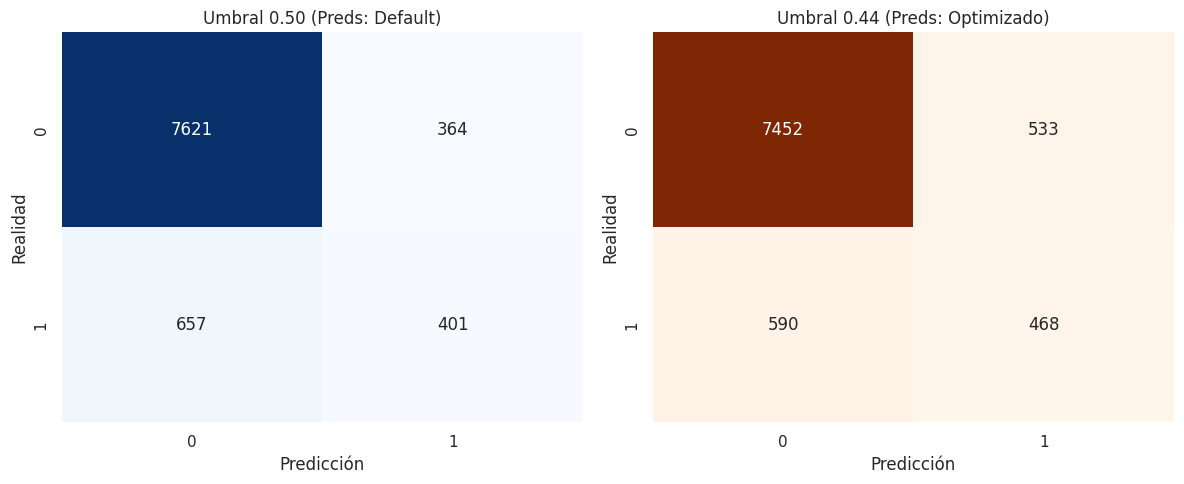

In [6]:
# Comparar Matrices de Confusión
cm_default = confusion_matrix(y_test, y_pred_default)
cm_opt = confusion_matrix(y_test, y_pred_opt)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title(f"Umbral 0.50 (Preds: Default)")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Realidad")

sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[1])
axes[1].set_title(f"Umbral {best_threshold:.2f} (Preds: Optimizado)")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Realidad")

plt.tight_layout()
plt.show()


## Conclusiones de esta iteración

1. **Reducción de Falsos Positivos**: Al cambiar los pesos de la clase y hacer Feature Engineering, nuestra Precisión base subió drásticamente. De cada 100 llamadas sugeridas, ahora ~50 serán exitosas (Precisión ~46-52%), frente a las 27 del experimento anterior.
2. **Flexibilidad con el Umbral**: Si el área de negocio nos dice '¡Llamar es muy caro, no importa si perdemos clientes, sube la precisión!', simplemente subimos el umbral a `0.60` o `0.70`. Si nos dicen '¡Llamar es muy barato, llama a más gente!', bajamos el umbral a `0.30`.
3. **Modularidad**: Todo este notebook quedó sumamente limpio porque la verdadera magia matemática está viviendo en la carpeta `src/`. ¡Así se construye software de Machine Learning!
